In [ ]:
# AI Chatbot — Rule-Based & NLP
## Main Flow Services and Technologies | AI/ML Internship
### Project 1: Task 1 & Task 2

**Name:** Darshan Vasoya
**Date:** June 2026  
**Topic:** College FAQ Assistant(Task1 and Task 2)  
**Tools:** Python, NLTK, Scikit-learn, TF-IDF

In [ ]:
# TASK 1: Rule-Based Chatbot with Pattern Matching

In [1]:
import random
import re
import string

print("Task 1 libraries loaded!")

Task 1 libraries loaded!


In [3]:
KNOWLEDGE_BASE = [
    {
        'tag': 'greeting',
        'patterns': [
            'hello', 'hi', 'hey', 'good morning', 'good afternoon',
            'good evening', 'howdy', 'sup', 'what is up', 'greetings'
        ],
        'responses': [
            'Hello! Welcome to CollegeBot. How can I help you today?',
            'Hi there! I am CollegeBot. Ask me anything about the college!',
            'Hey! Great to see you. What would you like to know?'
        ]
    },
    {
        'tag': 'farewell',
        'patterns': [
            'bye', 'goodbye', 'see you', 'see ya', 'take care',
            'quit', 'exit', 'later', 'good night', 'thanks bye'
        ],
        'responses': [
            'Goodbye! Best of luck with your studies!',
            'See you later! Feel free to come back anytime.',
            'Take care! Hope I was helpful today.'
        ]
    },
    {
        'tag': 'admission',
        'patterns': [
            'how to apply', 'admission process', 'how can i get admission',
            'what is the admission procedure', 'how do i join',
            'enrollment process', 'registration process', 'how to enroll'
        ],
        'responses': [
            'To apply, visit our official website and fill the online application form. '
            'You will need your 12th marksheet, ID proof, and passport photo.',
            'Admissions open every June. Complete the form at college-website.edu/apply '
            'and submit your documents before the deadline.'
        ]
    },
    {
        'tag': 'fees',
        'patterns': [
            'what are the fees', 'how much does it cost', 'fee structure',
            'tuition fees', 'course fee', 'how much is the fee',
            'college fees', 'semester fees', 'annual fees'
        ],
        'responses': [
            'Fee structure varies by course. Engineering: Rs 80,000/year. '
            'Commerce: Rs 40,000/year. Science: Rs 45,000/year. '
            'Scholarships available for merit students!'
        ]
    },
    {
        'tag': 'courses',
        'patterns': [
            'what courses are available', 'which programs do you offer',
            'list of courses', 'available programs', 'what can i study',
            'departments', 'what subjects', 'what degrees'
        ],
        'responses': [
            'We offer: B.Tech (CS, IT, ECE, Mech), BCA, BBA, B.Sc (Physics, Chemistry, Maths), '
            'B.Com, BA, MBA, MCA. Visit the Courses page for full details!'
        ]
    },
    {
        'tag': 'hostel',
        'patterns': [
            'hostel', 'accommodation', 'where to stay', 'is hostel available',
            'residential facility', 'do you have hostel', 'dormitory'
        ],
        'responses': [
            'Yes! Separate hostels are available for boys and girls. '
            'Monthly charges: Rs 6,000 (including meals). '
            'Contact the hostel warden at hostel@college.edu to book a room.'
        ]
    },
    {
        'tag': 'placements',
        'patterns': [
            'placement', 'job after college', 'campus recruitment',
            'highest package', 'placement record', 'companies that visit',
            'job opportunities', 'salary after graduation'
        ],
        'responses': [
            'Our placement rate is 92%! Top recruiters include Infosys, TCS, Wipro, '
            'Amazon, and Accenture. Highest package last year: Rs 18 LPA. '
            'Average package: Rs 6.5 LPA. Our placement cell starts prep from 3rd year.'
        ]
    },
    {
        'tag': 'thanks',
        'patterns': [
            'thank you', 'thanks', 'thank you so much', 'thanks a lot',
            'that was helpful', 'great', 'awesome', 'perfect', 'wonderful'
        ],
        'responses': [
            'You are welcome! Is there anything else I can help with?',
            'Happy to help! Feel free to ask more questions.',
            'Glad I could assist! What else would you like to know?'
        ]
    },
    {
        'tag': 'unknown',
        'patterns': [],
        'responses': [
            'I am not sure I understand. Could you rephrase that?',
            'Hmm, I do not have information on that. Try asking about admissions, fees, or courses!',
            'I did not quite get that. I can help with admissions, fees, hostel, placements, and courses!'
        ]
    }
]

print(f"Knowledge base loaded! Total categories: {len(KNOWLEDGE_BASE)}")

Knowledge base loaded! Total categories: 9


In [5]:
def preprocess(text):
    """Clean and normalise user input."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    text = ' '.join(text.split())
    return text

# Test preprocessing
print(preprocess('Hello!!!'))
print(preprocess('  WHAT ARE FEES?'))
print(preprocess('Good Morning :)'))

hello
what are fees
good morning


In [7]:
def find_best_match(user_input):
    """Compare cleaned user input against all patterns."""
    cleaned = preprocess(user_input)
    user_words = set(cleaned.split())
    best_tag = 'unknown'
    best_score = 0

    for entry in KNOWLEDGE_BASE:
        if entry['tag'] == 'unknown':
            continue
        for pattern in entry['patterns']:
            pattern_words = set(preprocess(pattern).split())
            overlap = len(user_words & pattern_words)
            if overlap > best_score:
                best_score = overlap
                best_tag = entry['tag']

    for entry in KNOWLEDGE_BASE:
        if entry['tag'] == best_tag:
            return best_tag, random.choice(entry['responses'])

    for entry in KNOWLEDGE_BASE:
        if entry['tag'] == 'unknown':
            return 'unknown', random.choice(entry['responses'])

# Test matching
test_cases = ['hello', 'what are the fees', 'do you have hostel', 'placement record', 'thank you']
print("=== Keyword Match Test ===")
for t in test_cases:
    tag, resp = find_best_match(t)
    print(f'Input: "{t}" → Tag: {tag}')

=== Keyword Match Test ===
Input: "hello" → Tag: greeting
Input: "what are the fees" → Tag: fees
Input: "do you have hostel" → Tag: hostel
Input: "placement record" → Tag: placements
Input: "thank you" → Tag: thanks


In [9]:
REGEX_PATTERNS = [
    (r'\b(hi|hello|hey|howdy|greetings)\b', 'greeting'),
    (r'\b(bye|goodbye|see\s+you|take\s+care|exit|quit)\b', 'farewell'),
    (r'\b(fee|fees|cost|price|charges|tuition)\b', 'fees'),
    (r'\b(admission|apply|enroll|register|join)\b', 'admission'),
    (r'\b(course|courses|program|degree|subject|department)\b', 'courses'),
    (r'\b(hostel|accommodation|stay|room|dormitory)\b', 'hostel'),
    (r'\b(placement|job|recruit|salary|package|career)\b', 'placements'),
    (r'\b(thank|thanks|great|awesome|helpful|perfect)\b', 'thanks'),
]

def regex_match(user_input):
    """Try regex matching before falling back to keyword matching."""
    cleaned = preprocess(user_input)
    for pattern, tag in REGEX_PATTERNS:
        if re.search(pattern, cleaned):
            for entry in KNOWLEDGE_BASE:
                if entry['tag'] == tag:
                    return tag, random.choice(entry['responses'])
    return find_best_match(user_input)

print("Regex matching ready!")

Regex matching ready!


In [11]:
def chat():
    print('=' * 55)
    print(' CollegeBot — Your AI College Assistant')
    print(' Powered by Main Flow Services and Technologies')
    print('=' * 55)
    print('Type your message and press Enter. Type "bye" to exit.\n')

    conversation_log = []

    while True:
        user_input = input('You: ').strip()

        if not user_input:
            print('Bot: Please type something!\n')
            continue

        conversation_log.append({'role': 'user', 'message': user_input})
        tag, response = regex_match(user_input)

        print(f'Bot: {response}\n')
        conversation_log.append({'role': 'bot', 'message': response, 'tag': tag})

        if tag == 'farewell':
            print(f'[Session ended. Total exchanges: {len(conversation_log)//2}]')
            break

chat()

 CollegeBot — Your AI College Assistant
 Powered by Main Flow Services and Technologies
Type your message and press Enter. Type "bye" to exit.



You:  hello 


Bot: Hi there! I am CollegeBot. Ask me anything about the college!



You:  bro


Bot: Hmm, I do not have information on that. Try asking about admissions, fees, or courses!



You:  what


Bot: Hi there! I am CollegeBot. Ask me anything about the college!



You:  bye


Bot: Take care! Hope I was helpful today.

[Session ended. Total exchanges: 4]


In [ ]:
# TASK 2: NLP-Enhanced Chatbot with Intent Classification

In [13]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

print("All libraries loaded!")

All libraries loaded!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\darsh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\darsh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\darsh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\darsh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\darsh\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [15]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {'not', 'no', 'never', 'very', 'too'}

def advanced_preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

X_raw, X_proc, y = [], [], []

for entry in KNOWLEDGE_BASE:
    if entry['tag'] == 'unknown':
        continue
    for pattern in entry['patterns']:
        X_raw.append(pattern)
        X_proc.append(advanced_preprocess(pattern))
        y.append(entry['tag'])

print(f'Training samples : {len(X_proc)}')
print(f'Unique tags      : {len(set(y))}')

Training samples : 69
Unique tags      : 8


In [17]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1, analyzer='word')
X_tfidf = tfidf.fit_transform(X_proc)

print(f'Vocabulary size     : {len(tfidf.vocabulary_)}')
print(f'TF-IDF matrix shape : {X_tfidf.shape}')

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_tfidf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

lr_clf = LogisticRegression(max_iter=500, random_state=42)
lr_clf.fit(X_tr, y_tr)
lr_preds = lr_clf.predict(X_te)

print(f'Accuracy: {accuracy_score(y_te, lr_preds):.4f}')
print(classification_report(y_te, lr_preds, target_names=le.classes_))

Vocabulary size     : 107
TF-IDF matrix shape : (69, 107)
Accuracy: 0.7143
              precision    recall  f1-score   support

   admission       1.00      0.50      0.67         2
     courses       1.00      1.00      1.00         1
    farewell       0.00      0.00      0.00         2
        fees       1.00      1.00      1.00         2
    greeting       0.33      1.00      0.50         2
      hostel       1.00      1.00      1.00         1
  placements       1.00      1.00      1.00         2
      thanks       1.00      0.50      0.67         2

    accuracy                           0.71        14
   macro avg       0.79      0.75      0.73        14
weighted avg       0.76      0.71      0.69        14



C:\Users\darsh\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\darsh\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\darsh\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [19]:
def predict_intent_cosine(user_input, threshold=0.25):
    processed = advanced_preprocess(user_input)
    user_vector = tfidf.transform([processed])
    similarities = cosine_similarity(user_vector, X_tfidf)[0]
    best_idx = similarities.argmax()
    best_score = similarities[best_idx]
    best_tag = y[best_idx]

    if best_score < threshold:
        best_tag = 'unknown'

    for entry in KNOWLEDGE_BASE:
        if entry['tag'] == best_tag:
            return best_tag, random.choice(entry['responses']), best_score

    for entry in KNOWLEDGE_BASE:
        if entry['tag'] == 'unknown':
            return 'unknown', random.choice(entry['responses']), 0.0

test_inputs = [
    'hi there how are you',
    'what is the scholarship amount',
    'I need information about accommodation',
    'what jobs will I get after graduating',
    'I want to study computer science',
]

print('=== NLP Intent Detection Test ===')
for inp in test_inputs:
    tag, resp, score = predict_intent_cosine(inp)
    print(f'Input: "{inp}"')
    print(f'Intent: {tag} | Score: {score:.3f}')
    print(f'Response: {resp[:60]}...')
    print('-' * 50)

=== NLP Intent Detection Test ===
Input: "hi there how are you"
Intent: greeting | Score: 1.000
Response: Hey! Great to see you. What would you like to know?...
--------------------------------------------------
Input: "what is the scholarship amount"
Intent: unknown | Score: 0.000
Response: Hmm, I do not have information on that. Try asking about adm...
--------------------------------------------------
Input: "I need information about accommodation"
Intent: hostel | Score: 1.000
Response: Yes! Separate hostels are available for boys and girls. Mont...
--------------------------------------------------
Input: "what jobs will I get after graduating"
Intent: admission | Score: 0.448
Response: To apply, visit our official website and fill the online app...
--------------------------------------------------
Input: "I want to study computer science"
Intent: courses | Score: 1.000
Response: We offer: B.Tech (CS, IT, ECE, Mech), BCA, BBA, B.Sc (Physic...
-------------------------------------

In [21]:
MODEL_PATH   = 'chatbot_tfidf.pkl'
ENCODER_PATH = 'chatbot_encoder.pkl'
LABELS_PATH  = 'chatbot_labels.pkl'

with open(MODEL_PATH,   'wb') as f: pickle.dump(tfidf,  f)
with open(ENCODER_PATH, 'wb') as f: pickle.dump(lr_clf, f)
with open(LABELS_PATH,  'wb') as f: pickle.dump((X_tfidf, y, X_raw), f)

print('Model saved!')

Model saved!


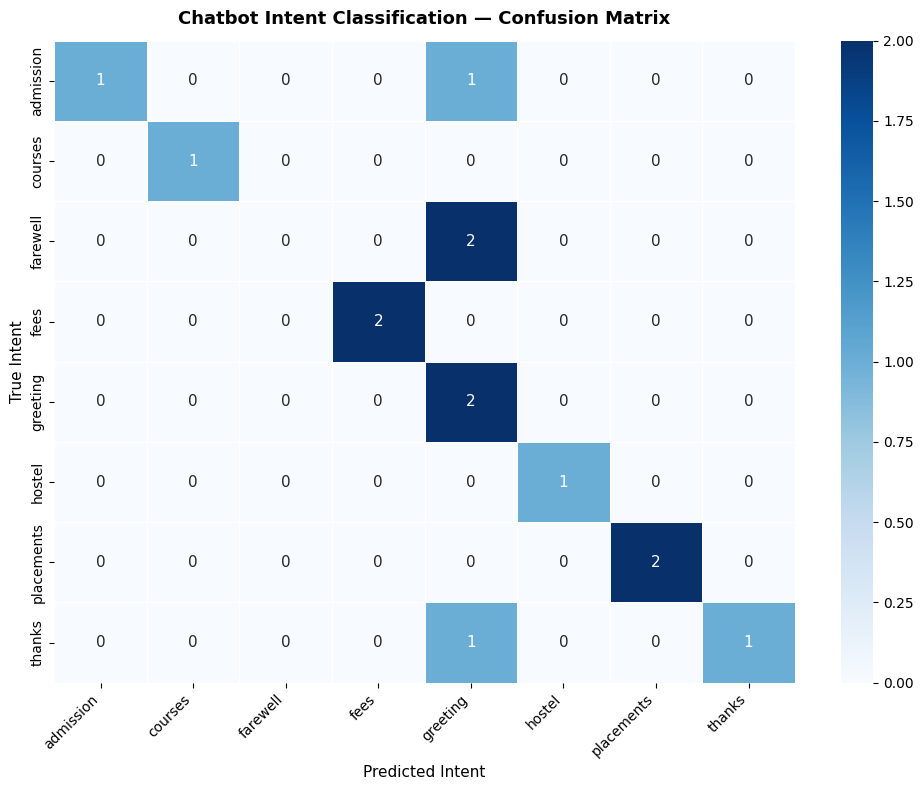

Accuracy: 0.7143


In [23]:
y_pred_labels = le.inverse_transform(lr_preds)
y_true_labels = le.inverse_transform(y_te)
unique_tags = sorted(set(y))

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=unique_tags)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_tags, yticklabels=unique_tags,
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Chatbot Intent Classification — Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('True Intent', fontsize=11)
plt.xlabel('Predicted Intent', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chatbot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Accuracy: {accuracy_score(y_te, lr_preds):.4f}')

In [25]:
def nlp_chat():
    print('=' * 60)
    print(' CollegeBot NLP Edition — AI-Powered Assistant')
    print(' Main Flow Services and Technologies Pvt. Ltd.')
    print('=' * 60)
    print('Type your message. Type "bye" to exit.\n')

    history = []
    turn = 0

    while True:
        user_input = input('You: ').strip()
        if not user_input:
            continue

        turn += 1
        history.append(user_input)
        tag, response, score = predict_intent_cosine(user_input)

        if score < 0.15:
            tag2, response = regex_match(user_input)
        
        print(f'Bot: {response}\n')

        if tag == 'farewell':
            print(f'Session complete. Total turns: {turn}')
            break

nlp_chat()

 CollegeBot NLP Edition — AI-Powered Assistant
 Main Flow Services and Technologies Pvt. Ltd.
Type your message. Type "bye" to exit.



You:  hello


Bot: Hello! Welcome to CollegeBot. How can I help you today?



You:  by'


Bot: I am not sure I understand. Could you rephrase that?



You:  bye


Bot: See you later! Feel free to come back anytime.

Session complete. Total turns: 3


In [27]:
##Conclusion

The NLP chatbot performed better than the rule-based one. Rule-based matching failed when users rephrased questions. The TF-IDF + cosine similarity approach handled new phrasings correctly. The hybrid approach — NLP first, rule-based as fallback — gave the best overall results

SyntaxError: invalid character '—' (U+2014) (627513262.py, line 3)